In [31]:
%matplotlib inline
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DB_CONFIG = {
    "host":     "localhost",
    "user":     "root",
    "password": "@Muzammil21",   
    "database": "university_fee_db"
}


# Color theme
BLUE      = "#1F4E79"
MID_BLUE  = "#2E75B6"
GREEN     = "#70AD47"
ORANGE    = "#ED7D31"
PURPLE    = "#7030A0"
TEAL      = "#00B0F0"
RED       = "#C00000"
COLORS    = [BLUE, MID_BLUE, GREEN, ORANGE, PURPLE, TEAL, "#FFC000", RED, "#FF6B6B"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        110,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
})

def run_query(sql):
    conn = mysql.connector.connect(**DB_CONFIG)
    df = pd.read_sql(sql, conn)
    conn.close()
    return df

try:
    conn = mysql.connector.connect(**DB_CONFIG)
    conn.close()
    print("✅ MySQL se connection ho gaya!")
except Exception as e:
    print(f"❌ Connection fail: {e}")
    print("   → Password check karo DB_CONFIG mein")

✅ MySQL se connection ho gaya!


In [32]:
print("Data load ho raha hai...")

students   = run_query("SELECT * FROM students")
dues       = run_query("SELECT * FROM dues")
payments   = run_query("SELECT * FROM payments")
schol_apps = run_query("""
    SELECT sa.*, sc.scholarship_type, sc.scholarship_name, sc.coverage_percent
    FROM scholarship_applications sa
    JOIN scholarships sc ON sa.scholarship_id = sc.scholarship_id
""")

print(f"Students loaded  : {len(students)}")
print(f"Dues loaded      : {len(dues)}")
print(f"Payments loaded  : {len(payments)}")
print(f"Scholarships     : {len(schol_apps)}")
print()
print("Students ka sample data:")
students

Data load ho raha hai...
Students loaded  : 200
Dues loaded      : 200
Payments loaded  : 150
Scholarships     : 39

Students ka sample data:


,student_id,reg_no,full_name,email,phone,program,department,semester,gpa,gender,admission_year,status,created_at
0,1,DS-2022-001,Ahmed Raza,ahmed.raza@uni.edu.pk,0301-1111001,BS Data Science,Data Science,6,3.85,Male,2022,Active,2026-05-26 15:02:04
1,2,DS-2022-002,Fatima Malik,fatima.malik@uni.edu.pk,0301-1111002,BS Data Science,Data Science,6,3.72,Female,2022,Active,2026-05-26 15:02:04
2,3,DS-2022-003,Usman Ali,usman.ali@uni.edu.pk,0301-1111003,BS Data Science,Data Science,6,3.10,Male,2022,Active,2026-05-26 15:02:04
3,4,DS-2022-004,Ayesha Khan,ayesha.khan@uni.edu.pk,0301-1111004,BS Data Science,Data Science,6,3.55,Female,2022,Active,2026-05-26 15:02:04
4,5,DS-2022-005,Bilal Hassan,bilal.hassan@uni.edu.pk,0301-1111005,BS Data Science,Data Science,6,2.85,Male,2022,Active,2026-05-26 15:02:04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,IT-2023-010,Jawwad Rehman,jawwad.rehman@uni.edu.pk,0304-4444026,BS IT,Information Technology,3,2.75,Male,2023,Active,2026-05-26 15:02:04
196,197,IT-2024-006,Lubaba Rashid,lubaba.rashid@uni.edu.pk,0304-4444027,BS IT,Information Technology,1,3.65,Female,2024,Active,2026-05-26 15:02:04
197,198,IT-2024-007,Qasim Javed,qasim.javed@uni.edu.pk,0304-4444028,BS IT,Information Technology,1,3.20,Male,2024,Active,2026-05-26 15:02:04
198,199,IT-2024-008,Samreen Bibi,samreen.bibi@uni.edu.pk,0304-4444029,BS IT,Information Technology,1,3.45,Female,2024,Active,2026-05-26 15:02:04


<!-- Chart 1 — KPI Summary Cards -->

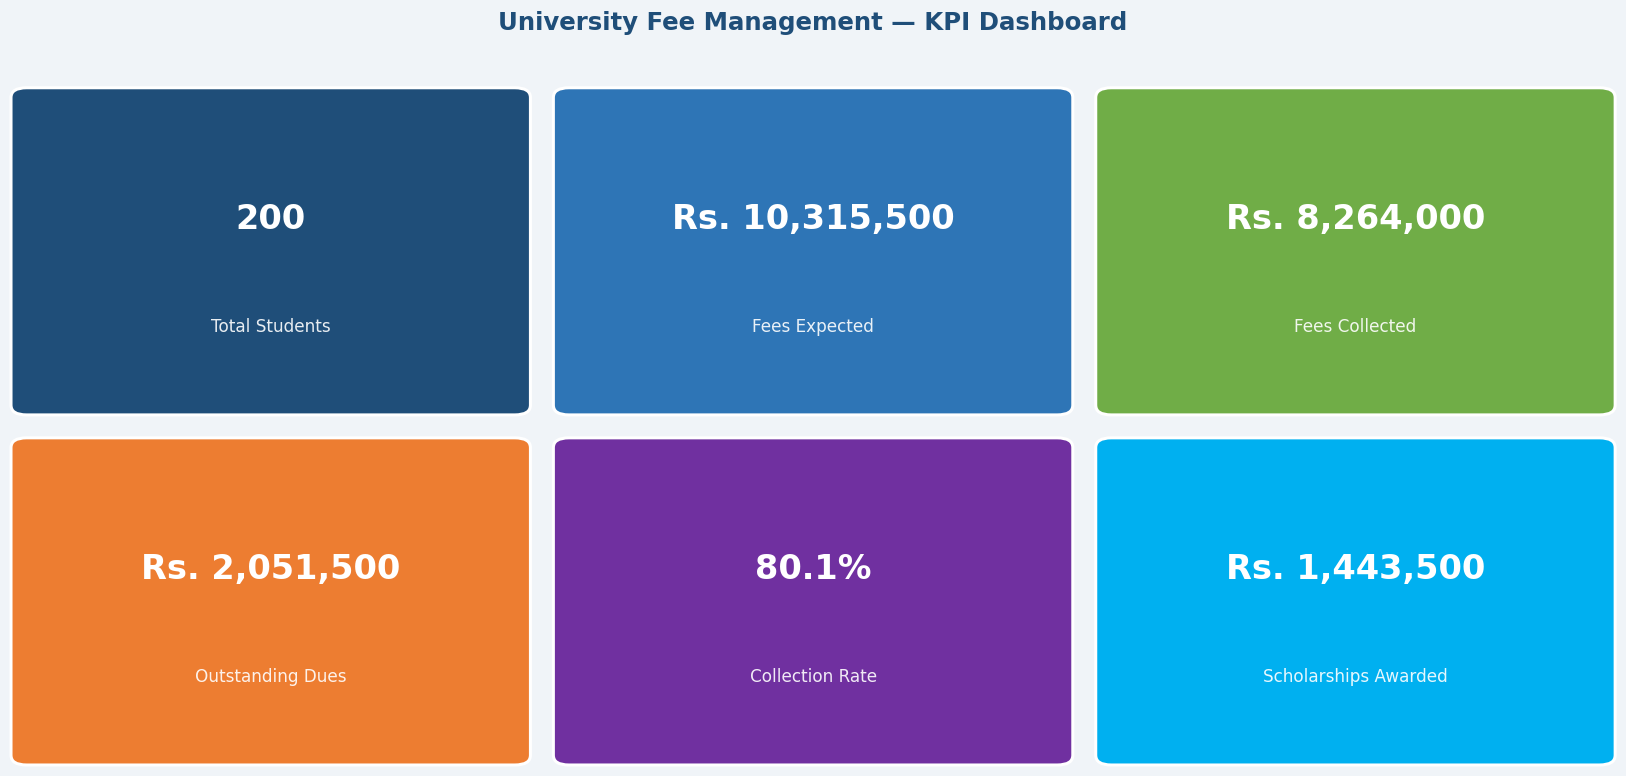

KPI Cards shown!


In [39]:
total_expected  = dues["total_fee"].sum()
total_collected = dues["amount_paid"].sum()
total_balance   = dues["balance"].sum()
total_fines     = dues["late_fine"].sum()
collection_rate = round(total_collected / total_expected * 100, 1)
approved = schol_apps[schol_apps["status"] == "Approved"]
total_schol     = approved["awarded_amount"].sum()

# ── KPI Data ───────────────────────────────────────────────
kpis = [
    ("Total Students",       str(len(students)),          "#1F4E79"),
    ("Fees Expected",        f"Rs. {total_expected:,.0f}", "#2E75B6"),
    ("Fees Collected",       f"Rs. {total_collected:,.0f}","#70AD47"),
    ("Outstanding Dues",     f"Rs. {total_balance:,.0f}",  "#ED7D31"),
    ("Collection Rate",      f"{collection_rate}%",        "#7030A0"),
    ("Scholarships Awarded", f"Rs. {total_schol:,.0f}",    "#00B0F0"),
]

# ── Chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.patch.set_facecolor("#F0F4F8")
fig.suptitle("University Fee Management — KPI Dashboard",
             fontsize=16, fontweight="bold", color="#1F4E79", y=1.01)

for ax, (title, value, color) in zip(axes.flatten(), kpis):
    
    
    rect = mpatches.FancyBboxPatch(
        (0.03, 0.03), 0.94, 0.94,
        boxstyle="round,pad=0.03",
        facecolor=color,
        edgecolor="white",
        linewidth=2,
        transform=ax.transAxes,
        clip_on=False,
        zorder=0
    )
    ax.add_patch(rect)
    
    # Value text (bada)
    ax.text(0.5, 0.60, value,
            ha="center", va="center",
            fontsize=22, fontweight="bold",
            color="white",
            transform=ax.transAxes,
            zorder=2)
    
    # Title text (chota)
    ax.text(0.5, 0.27, title,
            ha="center", va="center",
            fontsize=11, color="white",
            alpha=0.90,
            transform=ax.transAxes,
            zorder=2)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

plt.tight_layout(pad=1.5)
plt.show()
print("KPI Cards shown!")

Chart 2 - Department Wise Fee Collection

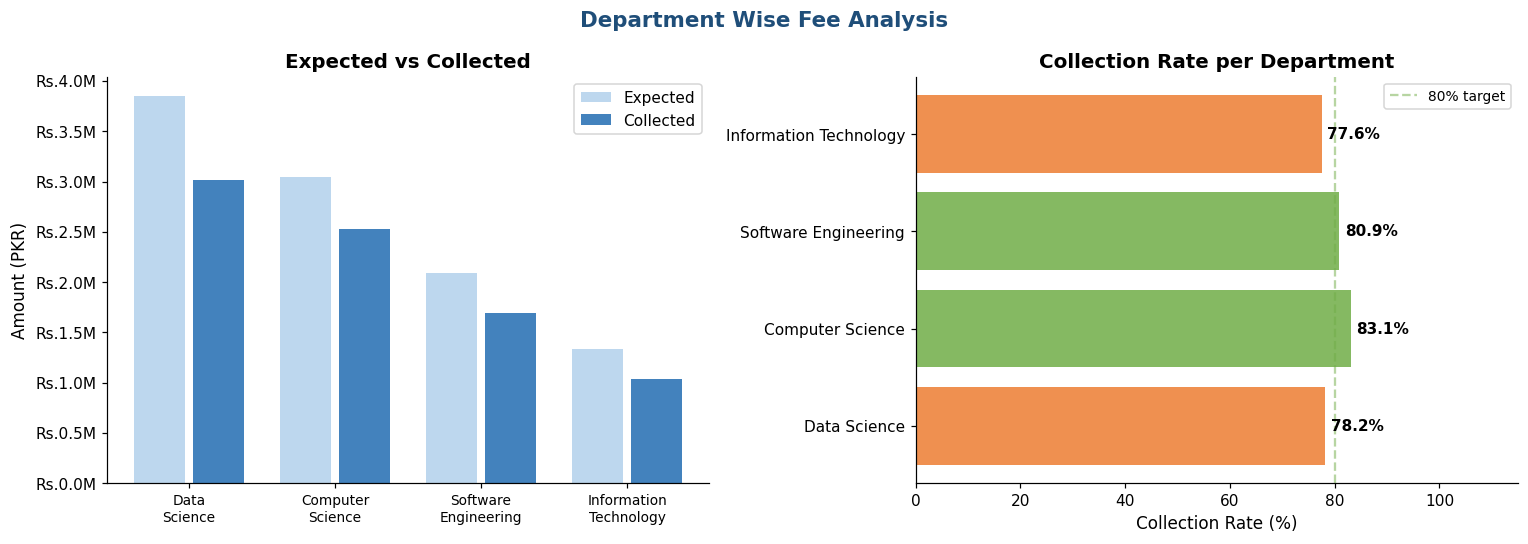

               department  total_students  total_expected  total_collected  \
0            Data Science              70       3850000.0        3010000.0   
1        Computer Science              60       3041500.0        2527000.0   
2    Software Engineering              40       2092000.0        1693000.0   
3  Information Technology              30       1332000.0        1034000.0   

   collection_rate_pct  
0                 78.2  
1                 83.1  
2                 80.9  
3                 77.6  


In [40]:
dept = run_query("""
    SELECT
        s.department,
        COUNT(DISTINCT s.student_id)                        AS total_students,
        SUM(d.total_fee)                                    AS total_expected,
        SUM(d.amount_paid)                                  AS total_collected,
        SUM(d.balance)                                      AS total_outstanding,
        ROUND(SUM(d.amount_paid)/SUM(d.total_fee)*100, 1)   AS collection_rate_pct,
        SUM(CASE WHEN d.status='Paid'    THEN 1 ELSE 0 END) AS paid_count,
        SUM(CASE WHEN d.status='Partial' THEN 1 ELSE 0 END) AS partial_count,
        SUM(CASE WHEN d.status IN ('Unpaid','Overdue') THEN 1 ELSE 0 END) AS unpaid_count
    FROM students s
    LEFT JOIN dues d ON s.student_id = d.student_id
    GROUP BY s.department
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Department Wise Fee Analysis", fontsize=14, fontweight="bold", color=BLUE)

# Left — Amount bar
x = range(len(dept))
bars1 = axes[0].bar([i-0.2 for i in x], dept["total_expected"],  0.35, 
                     color="#BDD7EE", label="Expected")
bars2 = axes[0].bar([i+0.2 for i in x], dept["total_collected"], 0.35, 
                     color=MID_BLUE,   label="Collected", alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels([d.replace(" ", "\n") for d in dept["department"]], fontsize=9)
axes[0].set_ylabel("Amount (PKR)")
axes[0].set_title("Expected vs Collected")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"Rs.{v/1e6:.1f}M"))
axes[0].legend()

# Right — Collection rate
colors_rate = [GREEN if r >= 80 else ORANGE if r >= 50 else RED 
               for r in dept["collection_rate_pct"]]
bars = axes[1].barh(dept["department"], dept["collection_rate_pct"],
                    color=colors_rate, alpha=0.85)
axes[1].set_xlabel("Collection Rate (%)")
axes[1].set_title("Collection Rate per Department")
axes[1].set_xlim(0, 115)
for bar, val in zip(bars, dept["collection_rate_pct"]):
    axes[1].text(val+1, bar.get_y()+bar.get_height()/2,
                 f"{val}%", va="center", fontweight="bold", fontsize=10)
axes[1].axvline(80, color=GREEN,  linestyle="--", alpha=0.5, label="80% target")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print(dept[["department","total_students","total_expected","total_collected","collection_rate_pct"]])

Chart 3 — Payment Status Breakdown (Paid / Partial / Unpaid

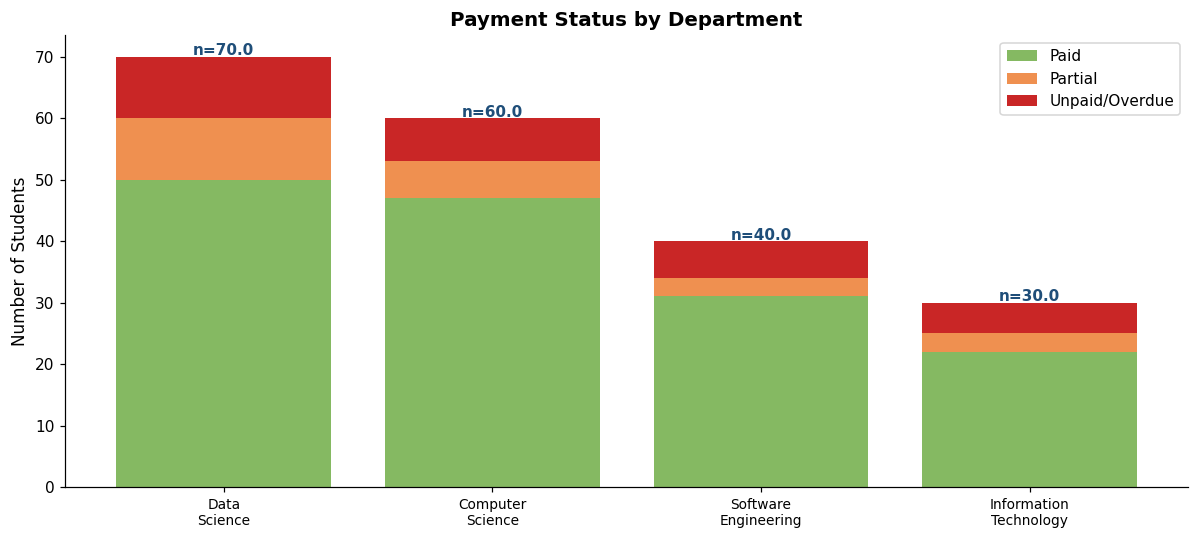

In [41]:
dept_status = run_query("""
    SELECT s.department,
        SUM(CASE WHEN d.status='Paid'                   THEN 1 ELSE 0 END) AS paid,
        SUM(CASE WHEN d.status='Partial'                THEN 1 ELSE 0 END) AS partial,
        SUM(CASE WHEN d.status IN ('Unpaid','Overdue')  THEN 1 ELSE 0 END) AS unpaid
    FROM students s
    LEFT JOIN dues d ON s.student_id = d.student_id
    GROUP BY s.department
""")

fig, ax = plt.subplots(figsize=(11, 5))
depts = dept_status["department"]
ax.bar(depts, dept_status["paid"],    color=GREEN,   label="Paid",         alpha=0.85)
ax.bar(depts, dept_status["partial"], color=ORANGE,  label="Partial",      alpha=0.85, bottom=dept_status["paid"])
ax.bar(depts, dept_status["unpaid"],  color=RED,     label="Unpaid/Overdue",alpha=0.85,
       bottom=dept_status["paid"]+dept_status["partial"])

for i, row in dept_status.iterrows():
    total = row["paid"] + row["partial"] + row["unpaid"]
    ax.text(i, total+0.2, f"n={total}", ha="center", fontsize=10, fontweight="bold", color=BLUE)

ax.set_title("Payment Status by Department")
ax.set_ylabel("Number of Students")
ax.legend()
ax.set_xticklabels([d.replace(" ",  "\n") for d in depts], fontsize=9)
plt.tight_layout()
plt.show()

Chart 4 — Scholarship Distribution

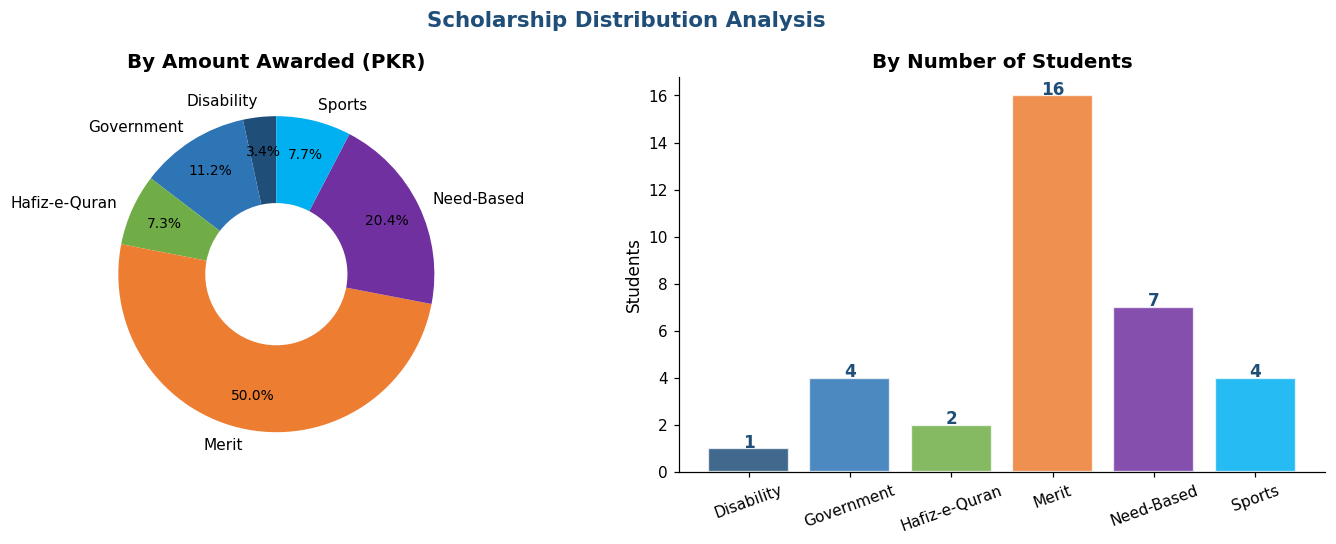


Scholarship Summary:
scholarship_type  Total Awarded (PKR)
      Disability              49000.0
      Government             162000.0
   Hafiz-e-Quran             106000.0
           Merit             722000.0
      Need-Based             294000.0
          Sports             110500.0


In [42]:
approved_schol = schol_apps[schol_apps["status"] == "Approved"]
by_type = approved_schol.groupby("scholarship_type")["awarded_amount"].sum().reset_index()
by_type = by_type[by_type["awarded_amount"] > 0]
count_type = approved_schol.groupby("scholarship_type").size().reset_index(name="count")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Scholarship Distribution Analysis", fontsize=14, fontweight="bold", color=BLUE)

# Donut chart
wedges, texts, autotexts = ax1.pie(
    by_type["awarded_amount"],
    labels=by_type["scholarship_type"],
    autopct="%1.1f%%",
    colors=COLORS[:len(by_type)],
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55)
)
for t in autotexts: t.set_fontsize(9)
ax1.set_title("By Amount Awarded (PKR)")

# Bar chart
ax2.bar(count_type["scholarship_type"], count_type["count"],
        color=COLORS[:len(count_type)], alpha=0.85, edgecolor="white", linewidth=1.5)
ax2.set_title("By Number of Students")
ax2.set_ylabel("Students")
ax2.tick_params(axis="x", rotation=20)
for i, row in count_type.iterrows():
    ax2.text(i, row["count"]+0.05, str(int(row["count"])),
             ha="center", fontsize=11, fontweight="bold", color=BLUE)
plt.tight_layout()
plt.show()

print("\nScholarship Summary:")
print(by_type.rename(columns={"awarded_amount":"Total Awarded (PKR)"}).to_string(index=False))

Chart 5 — Monthly Payment Trend

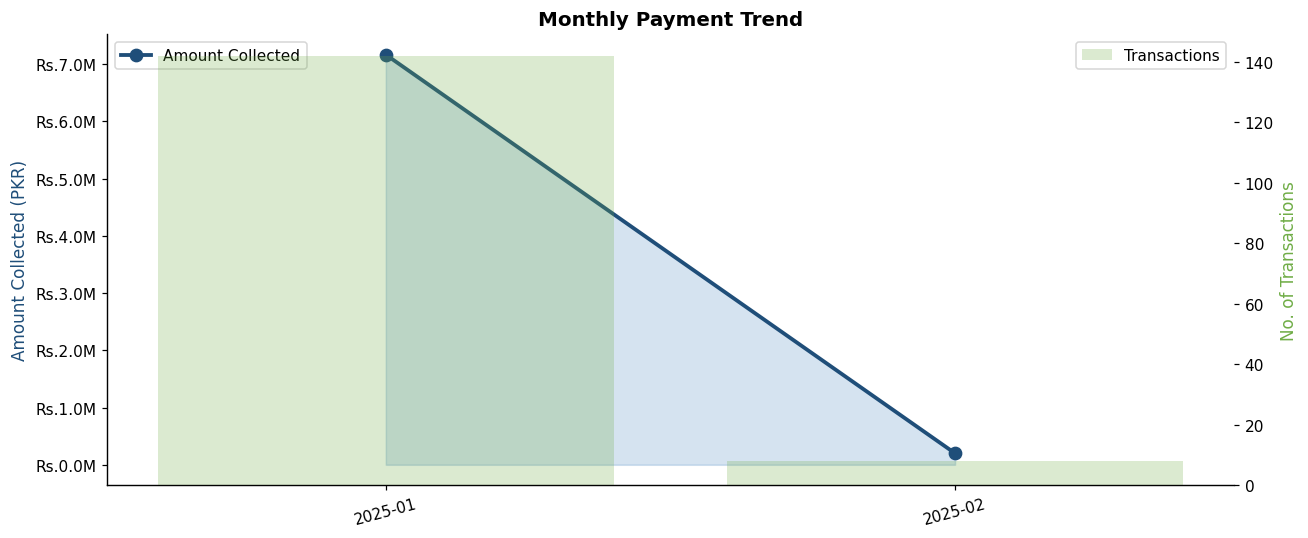

In [43]:
payments["payment_date"] = pd.to_datetime(payments["payment_date"])
monthly = payments.groupby(payments["payment_date"].dt.to_period("M"))["amount_paid"].agg(["sum","count"])
monthly.index = monthly.index.astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly.index, monthly["sum"], alpha=0.2, color=MID_BLUE)
ax1.plot(monthly.index, monthly["sum"],
         marker="o", color=BLUE, linewidth=2.5, markersize=8, label="Amount Collected")
ax2.bar(monthly.index, monthly["count"], alpha=0.25, color=GREEN, label="Transactions")

ax1.set_title("Monthly Payment Trend")
ax1.set_ylabel("Amount Collected (PKR)", color=BLUE)
ax2.set_ylabel("No. of Transactions",    color=GREEN)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"Rs.{v/1e6:.1f}M"))
ax1.tick_params(axis="x", rotation=15)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

Chart 6 — GPA Distribution by Program

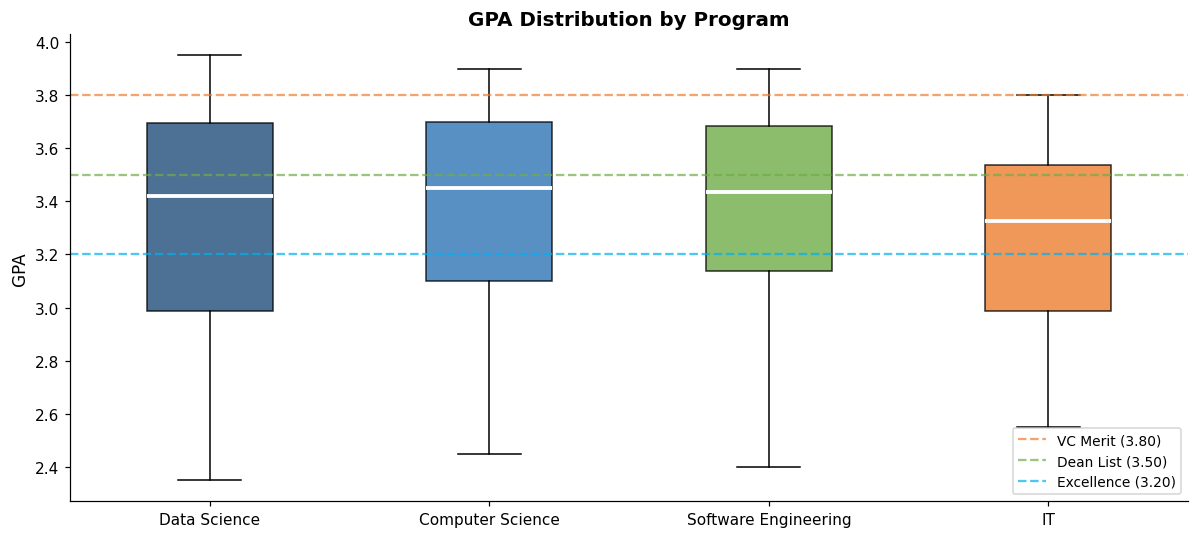

In [44]:
programs  = students["program"].unique()
data_prog = [students[students["program"] == p]["gpa"].values for p in programs]
short     = [p.replace("BS ", "") for p in programs]

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(data_prog, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2.5))
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels(short, fontsize=10)
ax.set_ylabel("GPA")
ax.set_title("GPA Distribution by Program")
ax.axhline(3.80, color=ORANGE, linestyle="--", alpha=0.7, label="VC Merit (3.80)")
ax.axhline(3.50, color=GREEN,  linestyle="--", alpha=0.7, label="Dean List (3.50)")
ax.axhline(3.20, color=TEAL,   linestyle="--", alpha=0.7, label="Excellence (3.20)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Chart 7 — GPA vs Scholarship Amount

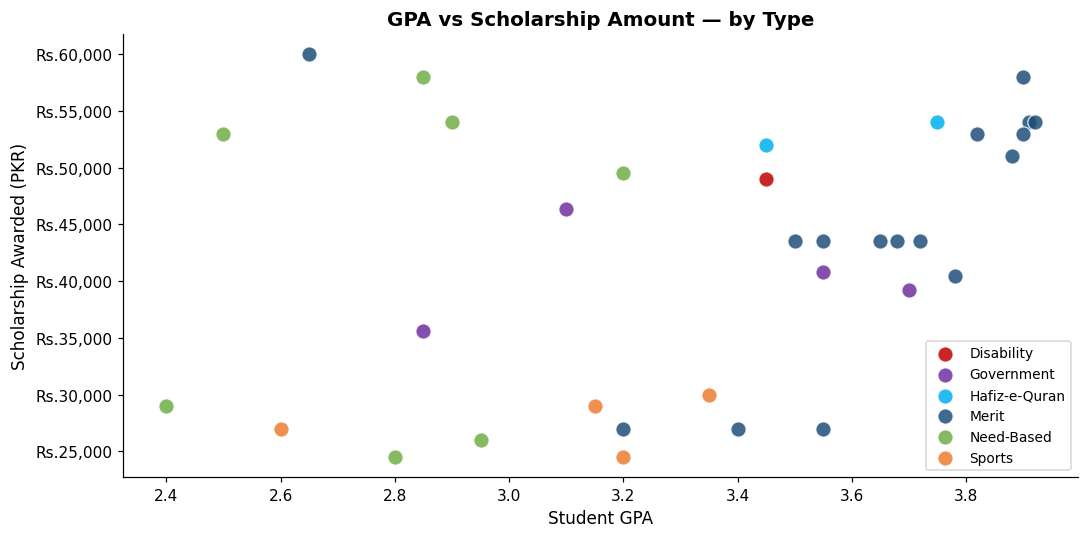

In [45]:
merged = pd.merge(
    students[["student_id","gpa","program"]],
    approved_schol[["student_id","awarded_amount","scholarship_type"]],
    on="student_id"
)
cmap = {"Merit":BLUE, "Need-Based":GREEN, "Sports":ORANGE,
        "Government":PURPLE, "Hafiz-e-Quran":TEAL, "Disability":RED}

fig, ax = plt.subplots(figsize=(10, 5))
for stype, grp in merged.groupby("scholarship_type"):
    ax.scatter(grp["gpa"], grp["awarded_amount"],
               label=stype, color=cmap.get(stype, MID_BLUE),
               s=100, alpha=0.85, edgecolors="white", linewidth=0.8)

ax.set_xlabel("Student GPA")
ax.set_ylabel("Scholarship Awarded (PKR)")
ax.set_title("GPA vs Scholarship Amount — by Type")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"Rs.{v:,.0f}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Chart 8 — Payment Method Analysis

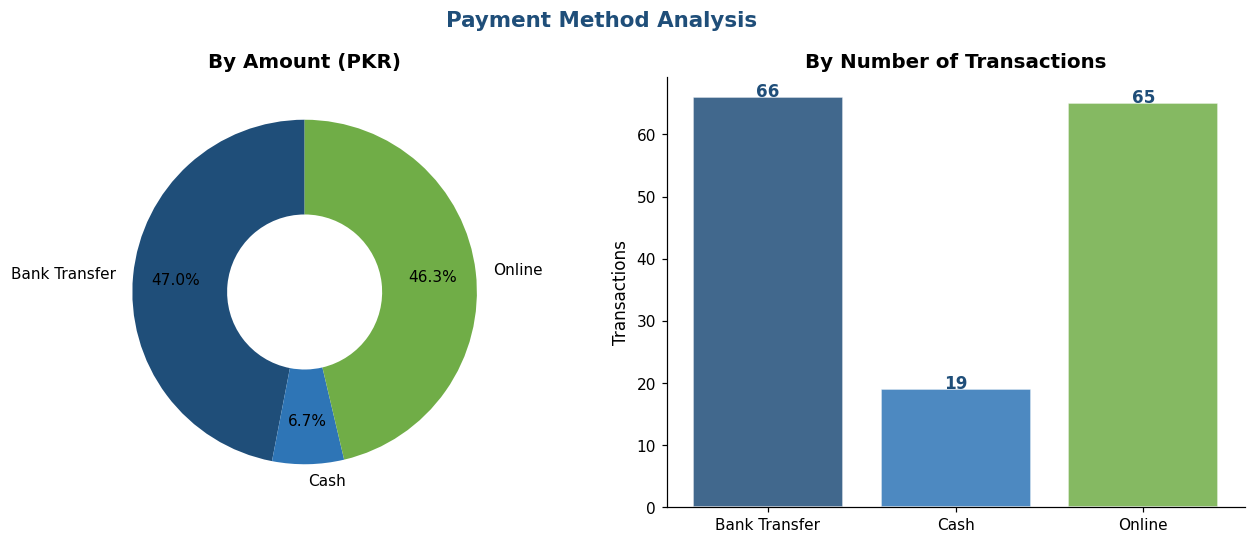

In [46]:
method = payments.groupby("payment_method").agg(
    total=("amount_paid","sum"),
    count=("payment_id","count")
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Payment Method Analysis", fontsize=14, fontweight="bold", color=BLUE)

wedges, texts, autotexts = ax1.pie(
    method["total"],
    labels=method["payment_method"],
    autopct="%1.1f%%",
    colors=COLORS[:len(method)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55)
)
for t in autotexts: t.set_fontsize(10)
ax1.set_title("By Amount (PKR)")

ax2.bar(method["payment_method"], method["count"],
        color=COLORS[:len(method)], alpha=0.85, edgecolor="white")
ax2.set_title("By Number of Transactions")
ax2.set_ylabel("Transactions")
for i, row in method.iterrows():
    ax2.text(i, row["count"]+0.1, str(int(row["count"])),
             ha="center", fontweight="bold", fontsize=11, color=BLUE)
plt.tight_layout()
plt.show()

Chart 9 — Student Distribution (Program × Semester)

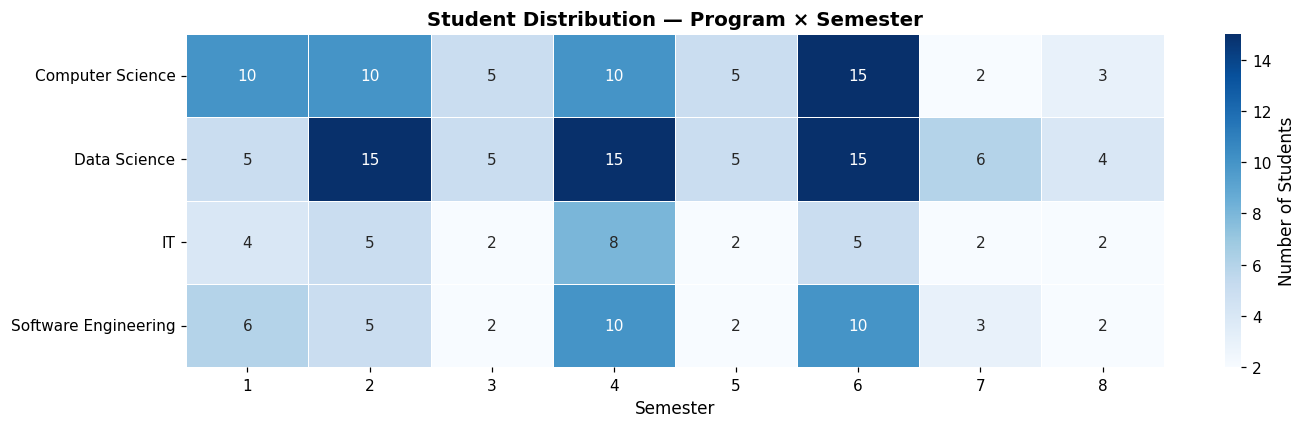

In [47]:
pivot = students.pivot_table(
    index="program", columns="semester",
    values="student_id", aggfunc="count", fill_value=0
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues",
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label":"Number of Students"})
ax.set_title("Student Distribution — Program × Semester")
ax.set_xlabel("Semester")
ax.set_ylabel("")
ax.set_yticklabels(
    [l.get_text().replace("BS ","") for l in ax.get_yticklabels()], rotation=0
)
plt.tight_layout()
plt.show()

Chart 10 — Top Defaulters (Overdue Students)

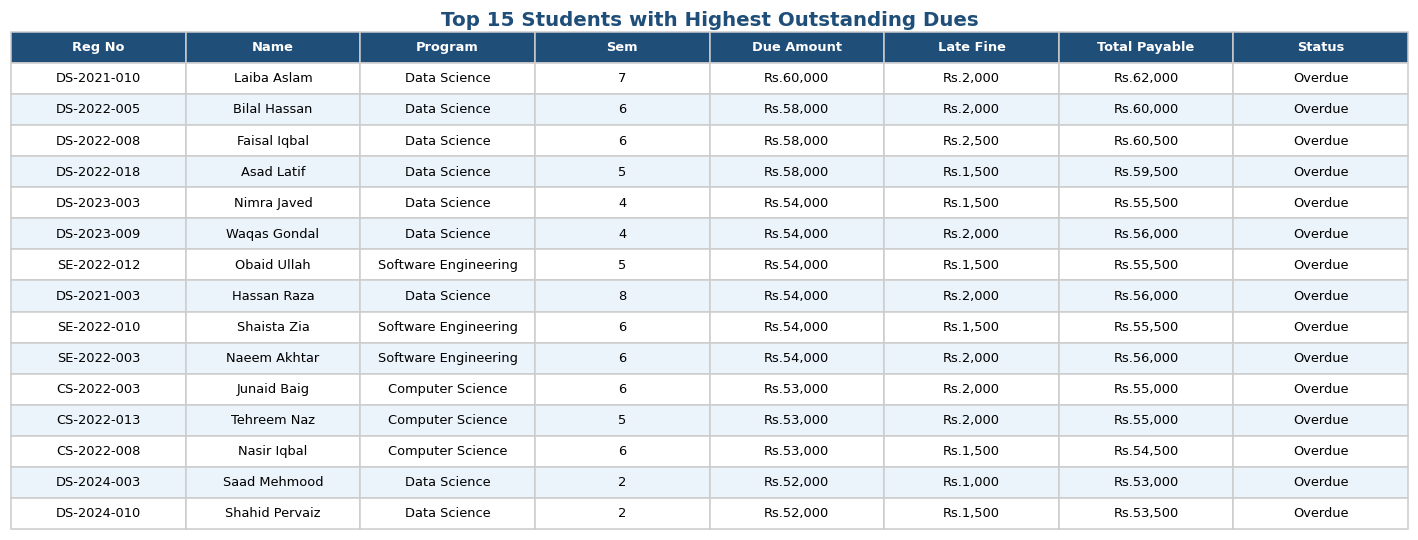


Total overdue/partial students: 15


In [48]:
overdue = run_query("""
    SELECT s.reg_no, s.full_name, s.program, s.semester, s.phone,
           d.balance AS amount_due, d.late_fine,
           (d.balance + d.late_fine) AS total_payable, d.status
    FROM students s
    JOIN dues d ON s.student_id = d.student_id
    WHERE d.balance > 0
    ORDER BY d.balance DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")
table_data = []
for _, row in overdue.iterrows():
    table_data.append([
        row["reg_no"], row["full_name"][:20],
        row["program"].replace("BS ",""),
        row["semester"],
        f"Rs.{row['amount_due']:,.0f}",
        f"Rs.{row['late_fine']:,.0f}",
        f"Rs.{row['total_payable']:,.0f}",
        row["status"]
    ])

cols = ["Reg No","Name","Program","Sem","Due Amount","Late Fine","Total Payable","Status"]
tbl = ax.table(cellText=table_data, colLabels=cols,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.6)

for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor(BLUE)
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EBF3FB")
    cell.set_edgecolor("#CCCCCC")

ax.set_title("Top 15 Students with Highest Outstanding Dues",
             fontsize=13, fontweight="bold", color=BLUE, pad=20)
plt.tight_layout()
plt.show()

print(f"\nTotal overdue/partial students: {len(overdue)}")

Final Summary Report

In [50]:
print("=" * 55)
print("   UNIVERSITY FEE MANAGEMENT — FINAL SUMMARY")
print("=" * 55)
print(f"  Total Students         : {len(students)}")
print(f"  Total Fees Expected    : Rs. {total_expected:>12,.0f}")
print(f"  Total Fees Collected   : Rs. {total_collected:>12,.0f}")
print(f"  Total Outstanding      : Rs. {total_balance:>12,.0f}")
print(f"  Late Fines Charged     : Rs. {total_fines:>12,.0f}")
print(f"  Collection Rate        : {collection_rate}%")
print(f"  Scholarships Awarded   : Rs. {total_schol:>12,.0f}")
print()
print("  Payment Status Breakdown:")
for status, count in dues["status"].value_counts().items():
    pct = round(count/len(dues)*100, 1)
    bar = "█" * int(pct/5)
    print(f"    {status:<12}: {bar:<20} {count:>3} students ({pct}%)")
print()
print("  Students by Program:")
for prog, count in students["program"].value_counts().items():
    print(f"    {prog:<30}: {count} students")
print("=" * 55)
print("\nAnalysis complete!")

   UNIVERSITY FEE MANAGEMENT — FINAL SUMMARY
  Total Students         : 200
  Total Fees Expected    : Rs.   10,315,500
  Total Fees Collected   : Rs.    8,264,000
  Total Outstanding      : Rs.    2,051,500
  Late Fines Charged     : Rs.       60,600
  Collection Rate        : 80.1%
  Scholarships Awarded   : Rs.    1,443,500

  Payment Status Breakdown:
    Paid        : ███████████████      150 students (75.0%)
    Overdue     : ██                    28 students (14.0%)
    Partial     : ██                    22 students (11.0%)

  Students by Program:
    BS Data Science               : 70 students
    BS Computer Science           : 60 students
    BS Software Engineering       : 40 students
    BS IT                         : 30 students

Analysis complete!
